In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian import *
from scripts.self_consistency import *


In [22]:
t = 1
mu = -1.8* t
Y,X = 25,25

lattice = Lattice(X, Y, pbc_x=False, pbc_y=True)

U0 = 2.0 * t 
U = U0 * cp.ones(lattice.num_sites)
V0 = 2.0 * t 
V = V0 * cp.ones(lattice.num_sites)

#### Normal Metal

In [3]:
H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0
    H.set_block(i,j, block)

free_energy_nm = H.free_energy(U=0,V=0,V_prime=0, temperature=0, drop_matrix=False)

-1393.4277687993622


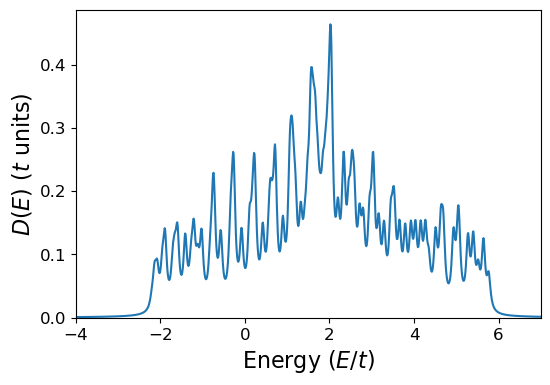

In [4]:
print(free_energy_nm)
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.05, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [23]:
gap_0 = 0.0 * t
gap_p= cp.array([0.1, 0.1j]) * t
gap_d = 0.0 *  t

H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)


In [24]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=None,V=V,V_prime=None,T=0,atol=1e-4,rtol=1e-1, max_iter=200, with_corr=True, verbose=True)


Iteration 1:                
Abs: 2.299579532693982                
Rel: 49.49747468305833                
Index: 124549                
Correlation:                 0j                
Corr_new:                 (-2.3418766925686896e-17+0.056619461301346756j)                
Correlation_dd:                     0j                
Corr_dd_new:                     (2.535245844097374e-16-2.15485181781494e-17j)                
Correlation_uu:                     0j                
Corr_uu_new:                     (8.056547525062173e-16-3.4865146658407883e-17j)
F0 bool: True
F bool: False
Fuu bool: True
Fdd bool: True


KeyboardInterrupt: 

In [7]:
print(H.free_energy(U=U0, V=V0, V_prime=V0, temperature=0, drop_matrix=False))
# -1149.1773795678719
# -1149.177379567772

-1410.9241467135782


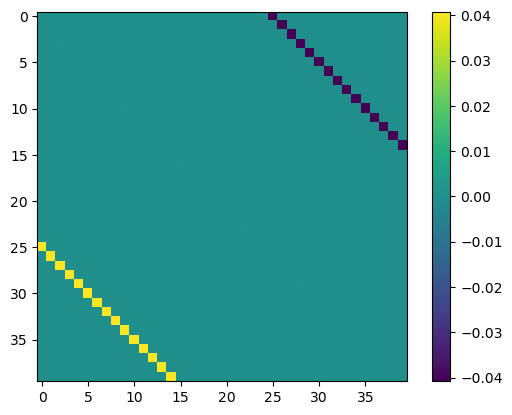

In [8]:
plt.figure()
plt.imshow(cp.asnumpy(cp.imag(F))[0:40,0:40])
colorbar = plt.colorbar()

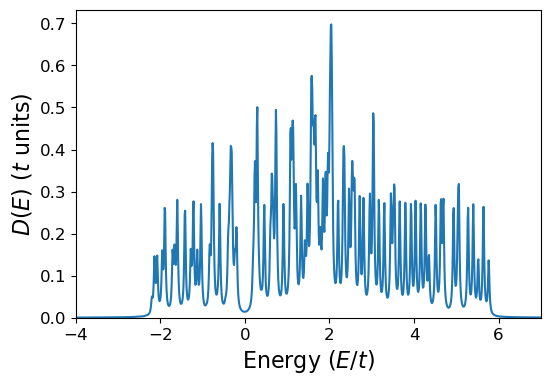

In [9]:
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Normal Metal: -1393.4277687993622
Free energy: -1410.9241467135782
-0.04080329939460859
-0.04080329939460859
2.9155736393154616e-18
-1.1614212604077141e-18


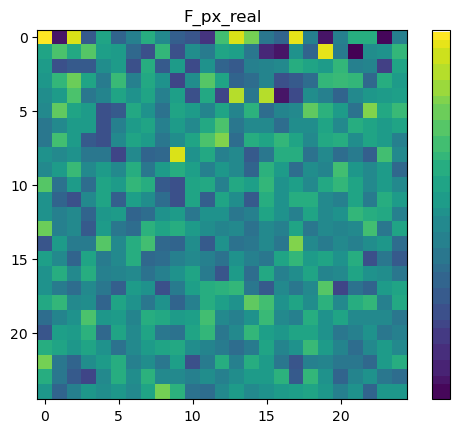

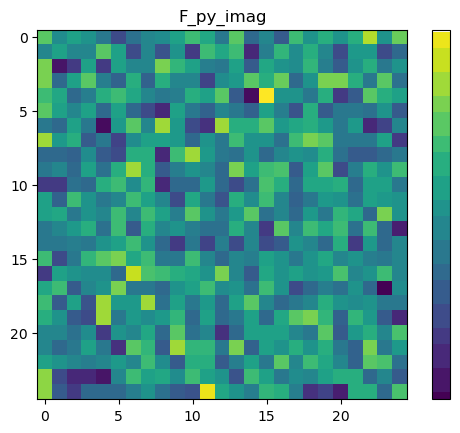

In [10]:
free_energy = H.free_energy(U=U0, V=V0, V_prime=V0, temperature=0, drop_matrix=False)
print(f"Normal Metal: {free_energy_nm}")
print(f"Free energy: {free_energy}")
F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += F[i][j]
        elif dir == "-x":
            F_xminus[i] += F[i][j]
        elif dir == "+y":
            F_yplus[i] += F[i][j]
        elif dir == "-y":
            F_yminus[i] += F[i][j]
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((F_xplus-F_xminus)/4).reshape(25,25))), label="F_T_real")
plt.title("F_px_real")
plt.colorbar()
print(np.average((np.real(cp.asnumpy((F_xplus-F_xminus)/2)))))
plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(25,25))), label="F_T_imag")
print(np.average((np.imag(cp.asnumpy((F_yplus-F_yminus)/2)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus+F_yplus+F_yminus)/4)))))

plt.title("F_py_imag")
plt.colorbar()

plt.show()

In [11]:
gap_0 = 0.0 * t
gap_p= cp.array([0.1, 0.1j]) * t
gap_d = 0.0 *  t

H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)
for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p_dd=gap_p, gap_p_uu=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p_dd=gap_p,gap_p_uu=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)


In [12]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=None,V=V,V_prime=V,T=0,atol=1e-3,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)

Iteration 1:                
Abs: 3.9661850528939165e-15                
Rel: 0.003966231296907428                
Index: 24                
Correlation:                 0j                
Corr_new:                 (5.177715500377827e-16+1.0139773838492562e-17j)                
Correlation_dd:                     0j                
Corr_dd_new:                     (-0.04735728001173586-5.708324438136181e-17j)                
Correlation_uu:                     0j                
Corr_uu_new:                     (-0.047357280011735885-1.919037845299343e-17j)
F0 bool: True
F bool: True
Fuu bool: False
Fdd bool: False
Iteration 2:                
Abs: 4.744950426871848e-15                
Rel: 0.004744950965228217                
Index: 31275                
Correlation:                 (3.583288180064592e-16-5.147249813874932e-17j)                
Corr_new:                 (-3.037663436761262e-16-3.981732478453015e-17j)                
Correlation_dd:                     (-0.047357280011

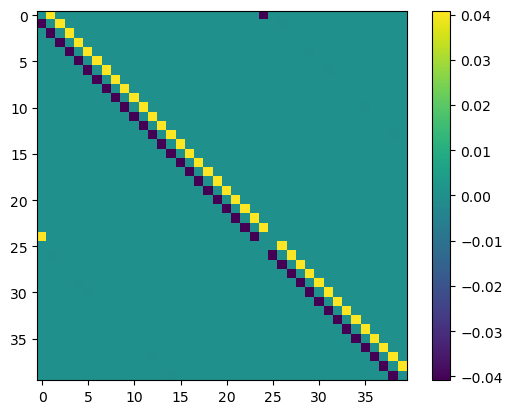

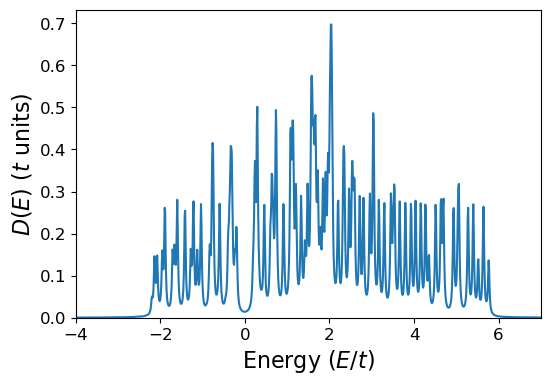

In [13]:
plt.figure()
plt.imshow(cp.asnumpy(cp.real(Fdd))[0:40,0:40])
colorbar = plt.colorbar()
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Normal Metal: -1393.4277687993622
Free energy: -1410.9241467135782
Free energy triplet: -1410.9637140624482


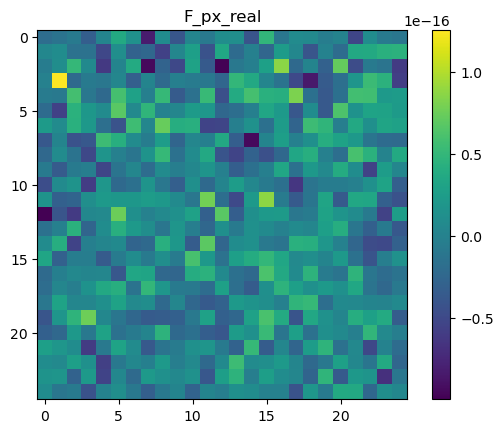

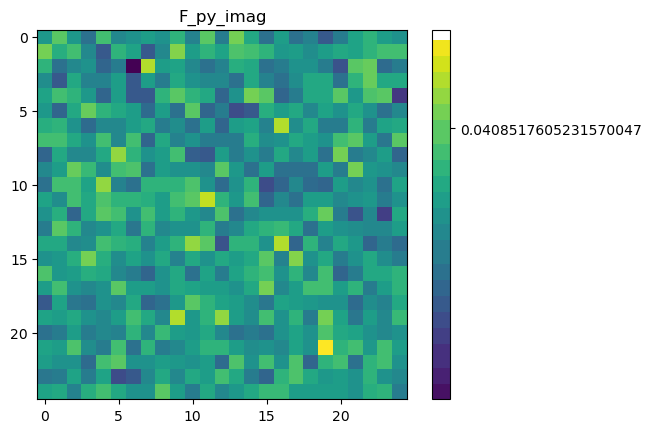

0.04085176052315695
0.04085176052315694
2.2021924892369828e-18
-5.1165279288780186e-18


In [14]:
free_energy_triplet = H.free_energy(U=U0, V=V0, V_prime=V0, temperature=0, drop_matrix=False)
print(f"Normal Metal: {free_energy_nm}")
print(f"Free energy: {free_energy}")
print(f"Free energy triplet: {free_energy_triplet}")
F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += Fdd[i][j]
        elif dir == "-x":
            F_xminus[i] += Fdd[i][j]
        elif dir == "+y":
            F_yplus[i] += Fdd[i][j]
        elif dir == "-y":
            F_yminus[i] += Fdd[i][j]
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4).reshape(25,25))), label="F_T_real")
plt.title("F_px_real")
plt.colorbar()

plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(25,25))), label="F_T_imag")
plt.title("F_py_imag")
plt.colorbar()
plt.show()

print(np.average((np.real(cp.asnumpy((F_xplus-F_xminus)/2)))))
print(np.average((np.imag(cp.asnumpy((F_yplus-F_yminus)/2)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4)))))
print(np.average((np.real(cp.asnumpy((F_xplus+F_xminus+F_yplus+F_yminus)/4)))))

In [15]:
gap_0 = 0.0 * t
gap_p= cp.array([0.0, 0.1j]) * t
gap_d = 0.1 *  t

H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p=gap_p, gap_d=gap_d)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p=gap_p, gap_d=gap_d)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)


In [16]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=None,V=V,V_prime=None,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)

Iteration 1:                
Abs: 2.4037355474596396                
Rel: 49.99999999955034                
Index: 45047                
Correlation:                 0j                
Corr_new:                 (-0.038389961300860836+0.044388253770099376j)                
Correlation_dd:                     0j                
Corr_dd_new:                     (2.5772840892696047e-16+5.963111948670274e-17j)                
Correlation_uu:                     0j                
Corr_uu_new:                     (4.077413320174861e-16-1.0674648014477595e-16j)
F0 bool: False
F bool: False
Fuu bool: True
Fdd bool: True
Iteration 2:                
Abs: 0.4572229559198119                
Rel: 15.638951080839274                
Index: 36307                
Correlation:                 (0.03432563858483322+1.5032798518400475e-16j)                
Corr_new:                 (0.024272462550027255+1.8013576915141106e-16j)                
Correlation_dd:                     (9.711740960038906e-17+1.6

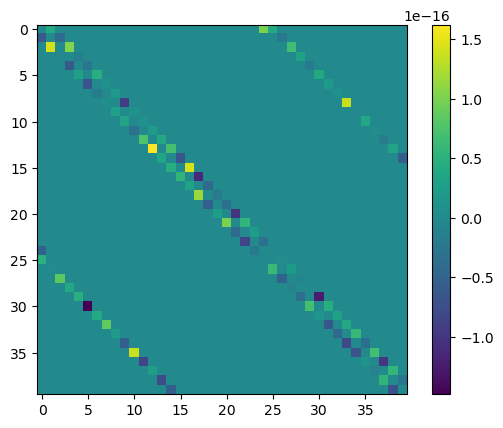

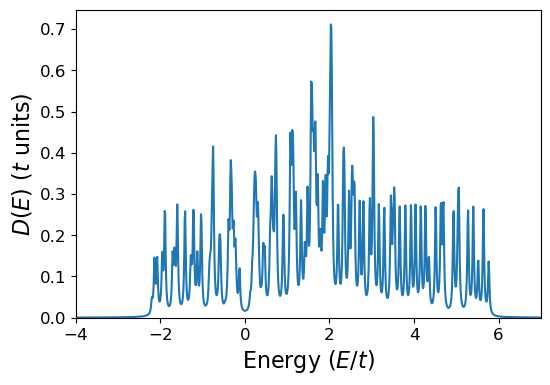

In [17]:
plt.figure()
plt.imshow(cp.asnumpy(cp.real(Fdd))[0:40,0:40])
colorbar = plt.colorbar()
energies = cp.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.02, drop_matrix=False)
plt.figure(figsize=(6,4))
plt.plot(cp.asnumpy(energies), cp.asnumpy(dos_values))
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Normal Metal: -1393.4277687993622
Free energy: -1410.9241467135782
Free energy triplet: -1410.9637140624482
Free energy d + ipy: -1407.8959767336546
(-5.53867219557809e-16+7.2734741680039435e-19j)
(3.485124515367755e-18-0.052471121824906757j)
(1.4269240264194088e-08-1.965094753586527e-18j)
(-6.79502206679882e-09+1.7208456881689928e-19j)


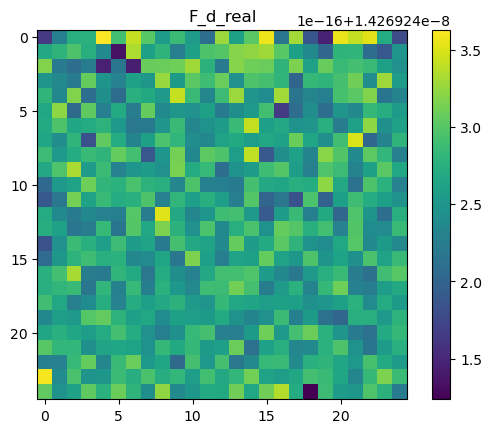

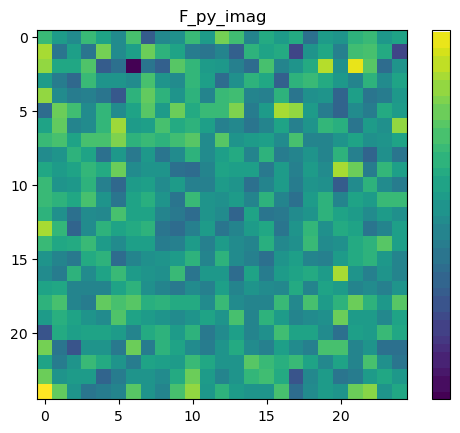

In [18]:
free_energy_dipy = H.free_energy(U=U0, V=V0, V_prime=V0, temperature=0, drop_matrix=False)
print(f"Normal Metal: {free_energy_nm}")
print(f"Free energy: {free_energy}")
print(f"Free energy triplet: {free_energy_triplet}")
print(f"Free energy d + ipy: {free_energy_dipy}")

F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

F_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
F_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            F_xplus[i] += F[i][j]
        elif dir == "-x":
            F_xminus[i] += F[i][j]
        elif dir == "+y":
            F_yplus[i] += F[i][j]
        elif dir == "-y":
            F_yminus[i] += F[i][j]
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4).reshape(25,25))), label="F_T_real")
plt.title("F_d_real")
plt.colorbar()
plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(25,25))), label="F_T_imag")
print(np.average(cp.asnumpy((F_xplus-F_xminus)/2)))
print(np.average(cp.asnumpy((F_yplus-F_yminus)/2)))
print(np.average(cp.asnumpy((F_xplus+F_xminus-F_yplus-F_yminus)/4)))
print(np.average(cp.asnumpy((F_xplus+F_xminus+F_yplus+F_yminus)/4)))

plt.title("F_py_imag")
plt.colorbar()

plt.show()

In [19]:
gap_0 = 0.0 * t
gap_p= cp.array([0.1, 0.1j]) * t
gap_d = 0.0 *  t

H = Hamiltonian(lattice)
block = cp.zeros((4, 4), dtype=cp.complex128)

for i in range(lattice.num_sites):
    block[:,:]=0
    block[:2, :2] = -mu * s0
    block[2:, 2:] = mu * s0
    block[:2, 2:] = -1j * gap_0 * s2
    block[2:, :2] = (-1j * gap_0 * s2).conj().T
    H.set_block(i,i, block)

for i, j in lattice.edges:
    block[:,:]=0
    block[0:2, 0:2] = -t * s0
    block[2:4, 2:4] = t * s0

    gap_ij = unconventional_gap(lattice.get_disp(i,j), gap_p_dd=gap_p)
    block[0:2, 2:4] = gap_ij
    gap_ji = unconventional_gap(lattice.get_disp(j,i), gap_p_dd=gap_p)
    block[2:4, 0:2] = gap_ji.conj().T

    H.set_block(i,j, block)


In [20]:
F0, F, Fuu, Fdd = bdg_self_consistency(H,U=None,V=None,V_prime=V,T=0,atol=1e-4,rtol=1e-1, max_iter=100, with_corr=True, verbose=True)

Iteration 1:                
Abs: 3.9885980576792546e-15                
Rel: 0.003988594418862936                
Index: 69485                
Correlation:                 0j                
Corr_new:                 (3.0819707791971166e-16-5.3869192406819884e-17j)                
Correlation_dd:                     0j                
Corr_dd_new:                     (-0.047357280011735864+2.5719308410429575e-17j)                
Correlation_uu:                     0j                
Corr_uu_new:                     (-3.527542079866449e-16+2.948506628894238e-17j)
F0 bool: True
F bool: True
Fuu bool: True
Fdd bool: False
Iteration 2:                
Abs: 5.699731143868113e-15                
Rel: 0.005699786524432639                
Index: 80753                
Correlation:                 (1.8286770611769584e-16+3.678163904415117e-17j)                
Corr_new:                 (-3.2695210885322066e-16+4.501282535553178e-17j)                
Correlation_dd:                     (0.04735

Normal Metal: -1393.4277687993622
Free energy: -1410.9241467135782
Free energy triplet: -1410.9637140624482
Free energy dd: -1402.1759577564703
Free energy d + ipy: -1407.8959767336546
(0.04080329939460859-1.2008476556342984e-17j)
(1.1010755770145786e-18+0.0408032993946086j)


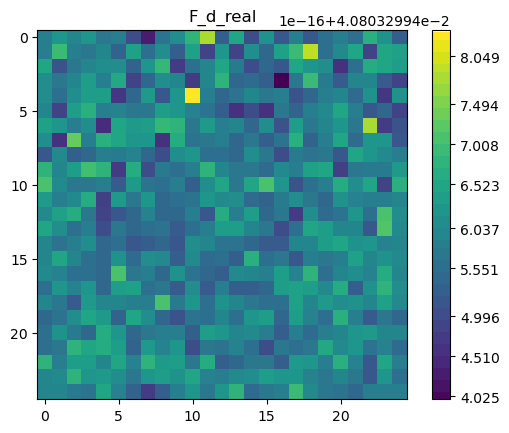

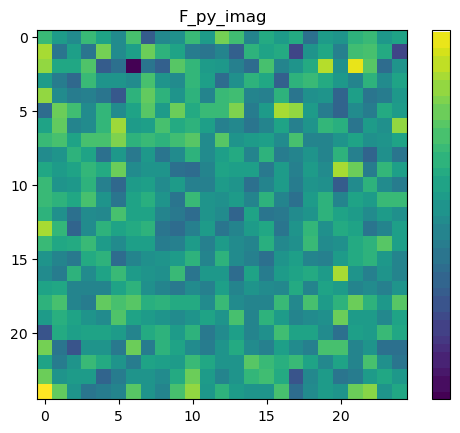

In [21]:
free_energy_dd = H.free_energy(U=U0, V=V0, V_prime=V0, temperature=0, drop_matrix=False)
print(f"Normal Metal: {free_energy_nm}")
print(f"Free energy: {free_energy}")
print(f"Free energy triplet: {free_energy_triplet}")
print(f"Free energy dd: {free_energy_dd}")
print(f"Free energy d + ipy: {free_energy_dipy}")

F_S = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)
F_T = cp.zeros((H.lattice.num_sites, H.lattice.num_sites), dtype=cp.complex128)

Fdd_xplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_xminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_yplus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)
Fdd_yminus = cp.zeros(H.lattice.num_sites, dtype=cp.complex128)

for i,j in H.lattice.edges:
        F_S[i][j] = (F[i][j]+F[j][i])/2
        F_T[i][j] = (F[i][j]-F[j][i])/2
        dir = H.lattice.get_dir(i,j)
        if dir == "+x":
            Fdd_xplus[i] += Fdd[i][j]
        elif dir == "-x":
            Fdd_xminus[i] += Fdd[i][j]
        elif dir == "+y":
            Fdd_yplus[i] += Fdd[i][j]
        elif dir == "-y":
            Fdd_yminus[i] += Fdd[i][j]
    
plt.figure()
plt.imshow((np.real(cp.asnumpy((Fdd_xplus-Fdd_xminus)/2).reshape(25,25))), label="F_T_real")
plt.title("F_d_real")
plt.colorbar()
plt.figure()
plt.imshow((np.imag(cp.asnumpy((F_yplus-F_yminus)/2).reshape(25,25))), label="F_T_imag")
print(np.average(cp.asnumpy((Fdd_xplus-Fdd_xminus)/2)))
print(np.average(cp.asnumpy((Fdd_yplus-Fdd_yminus)/2)))

plt.title("F_py_imag")
plt.colorbar()

plt.show()